In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, QuantileTransformer,KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

def parse_size_string(size_str):
    """
    Convert size strings like "64M" or "128M" to numeric values in bytes.
    """
    if isinstance(size_str, str):
        if size_str.endswith("K"):
            return int(size_str[:-1]) * 1024
        elif size_str.endswith("M"):
            return int(size_str[:-1]) * 1024 * 1024
        elif size_str.endswith("G"):
            return int(size_str[:-1]) * 1024 * 1024 * 1024
        else:
            return int(size_str)  # Assume bytes if no unit is specified
    return size_str  # Return as-is if already numeric


data = pd.read_csv("rocksdb_benchmark_results.csv")
data["write_buffer_size"] = data["write_buffer_size"].apply(parse_size_string)
data["block_cache_size"] = data["block_cache_size"].apply(parse_size_string)

data["latency_zscore"] = (data["latency"] - data["latency"].mean()) / data["latency"].std()

# Identify outliers (e.g., Z-score > 3 or Z-score < -3)
outliers = data[np.abs(data["latency_zscore"]) > 3]
print("Outliers detected:")
print(outliers)

# Remove outliers
data_cleaned = data[np.abs(data["latency_zscore"]) <= 3]

# Save cleaned data
data_cleaned.to_csv("rocksdb_benchmark_results_cleaned.csv", index=False)
print("Outliers removed and cleaned data saved.")


2025-02-24 16:25:02.703422: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Outliers detected:
     data_size operation_type  write_buffer_size  block_cache_size  \
5        10000            GET          134217728         134217728   
11       10000            GET          134217728          67108864   
315     200000            GET           67108864          67108864   

    compaction_style  max_background_jobs  bloom_filter_policy  latency  \
5          universal                    2                 True   304087   
11             level                    4                 True   218682   
315            level                    4                 True   153056   

     latency_zscore  
5         17.982186  
11        12.904376  
315        9.002539  
Outliers removed and cleaned data saved.


In [2]:
# Load the data
df = pd.read_csv("rocksdb_benchmark_results_cleaned.csv")

# Preprocessing: Convert string parameters to numerical
def convert_size_to_bytes(size_str):
    if isinstance(size_str, (int, np.int64)): # Handle already converted values
        return size_str
    unit = size_str[-1].upper()
    value = float(size_str[:-1])
    if unit == 'K':
        return int(value * 1024)
    elif unit == 'M':
        return int(value * 1024 * 1024)
    elif unit == 'G':
        return int(value * 1024 * 1024 * 1024)
    return int(value)

df['bloom_filter_policy'] = df['bloom_filter_policy'].replace({'true': 1, 'false': 0})

df


,data_size,operation_type,write_buffer_size,block_cache_size,compaction_style,max_background_jobs,bloom_filter_policy,latency,latency_zscore
0,10000,GET,134217728,134217728,level,2,False,34,-0.095484
1,10000,GET,134217728,134217728,level,2,True,29,-0.095781
2,10000,GET,134217728,134217728,level,4,False,30,-0.095721
3,10000,GET,134217728,134217728,level,4,True,27,-0.095900
4,10000,GET,134217728,134217728,universal,2,False,22,-0.096197
...,...,...,...,...,...,...,...,...,...
568,500000,SEEK,67108864,67108864,level,4,True,8,-0.097029
569,500000,SEEK,67108864,67108864,universal,2,False,10,-0.096911
570,500000,SEEK,67108864,67108864,universal,2,True,19,-0.096375
571,500000,SEEK,67108864,67108864,universal,4,False,10,-0.096911


Mean Squared Error: 99.52109527620787
R-squared: 0.9997845724592435


/Users/wesley/opt/anaconda3/envs/tensorflow_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2500) reached and the optimization hasn't converged yet.
  warnings.warn(


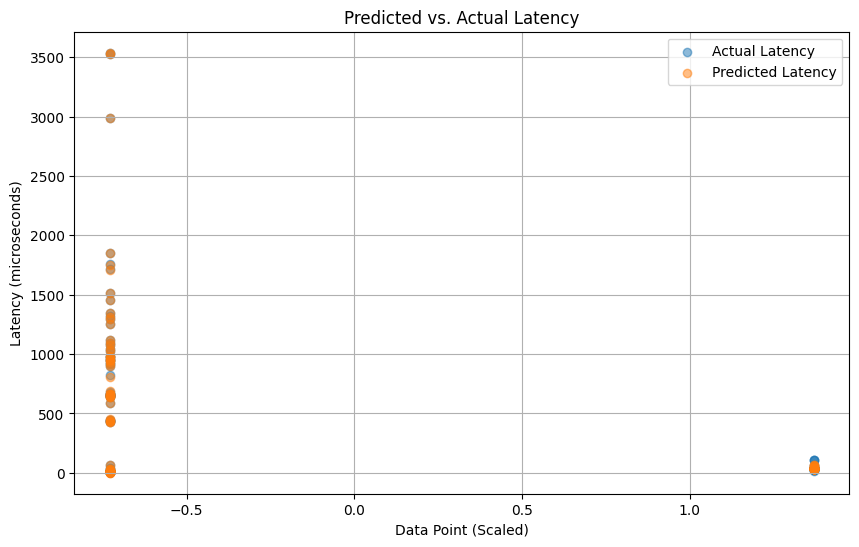

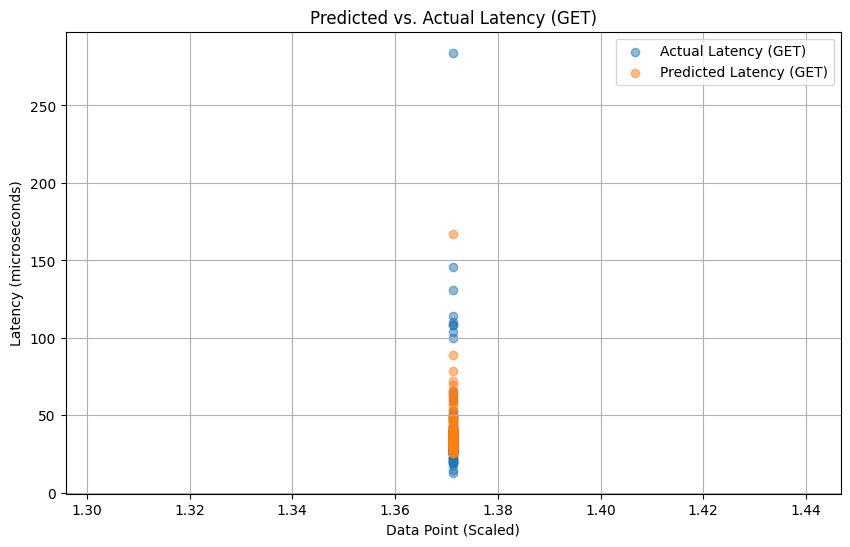

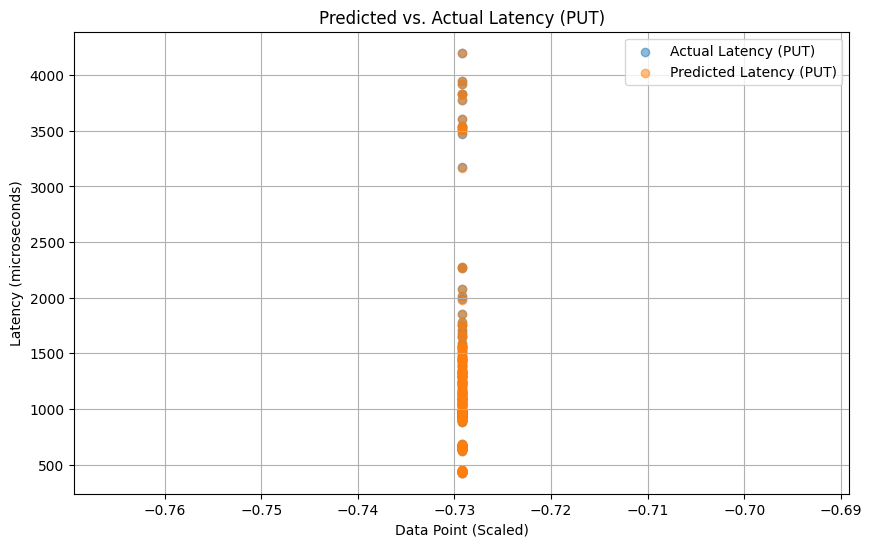

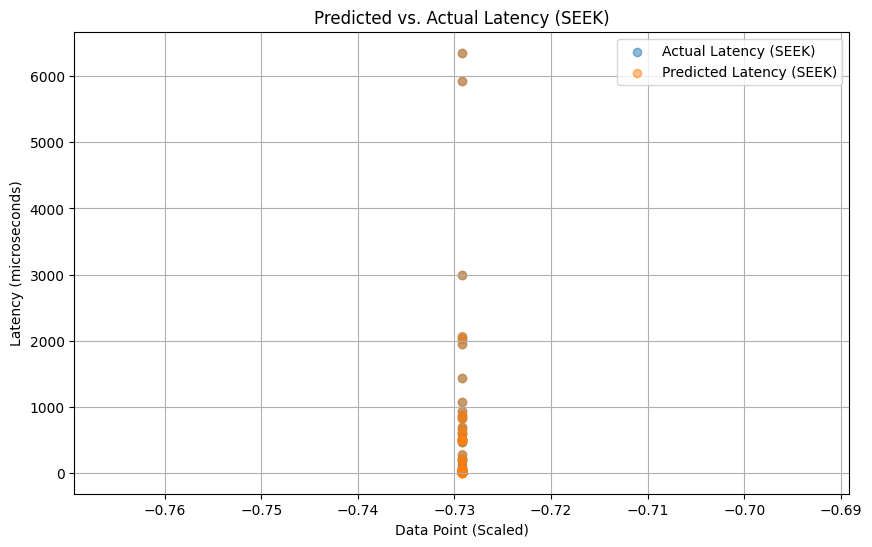

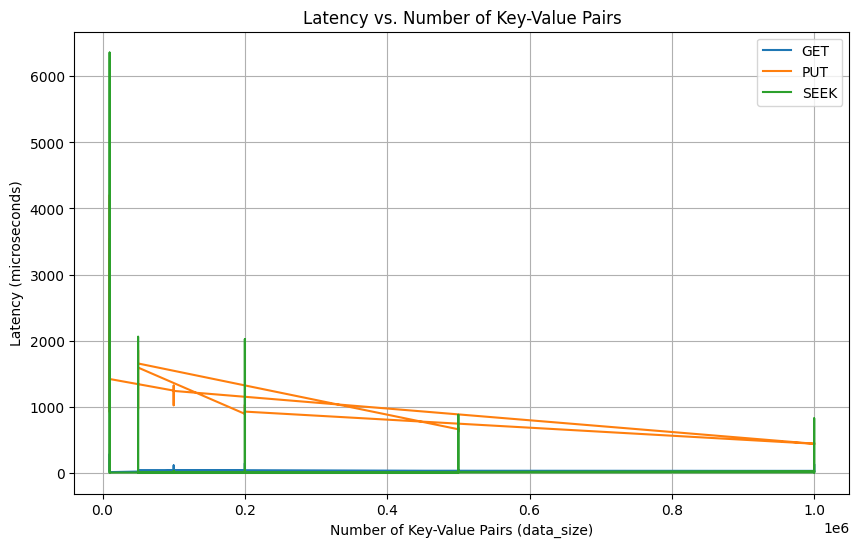

In [3]:
# One-hot encode categorical features
ct = ColumnTransformer([('encoder', OneHotEncoder(), ['operation_type', 'compaction_style'])], remainder='passthrough')
X = ct.fit_transform(df.drop('latency', axis=1))
y = df['latency']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

early_stopping = EarlyStopping(
    monitor="val_loss",  # Metric to monitor
    patience=10,         # Number of epochs to wait after the last improvement
    restore_best_weights=True  # Restore the best model weights
)


# Train the model
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', random_state=42, max_iter=2500)
mlp.fit(X_train, y_train)

# Make predictions
y_pred = mlp.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Visualization: Predicted vs. Actual latency (General)
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, label="Actual Latency", alpha=0.5) # x[:, 0] to avoid error.
plt.scatter(X_test[:, 0], y_pred, label="Predicted Latency", alpha=0.5) # x[:, 0] to avoid error.
plt.xlabel("Data Point (Scaled)") # x[:, 0] to avoid error.
plt.ylabel("Latency (microseconds)")
plt.title("Predicted vs. Actual Latency")
plt.legend()
plt.grid(True)
plt.show()

# More Detailed Visualization (per operation type):
for op_type in df['operation_type'].unique():
    op_df = df[df['operation_type'] == op_type]
    X_op = ct.transform(op_df.drop('latency', axis=1))
    X_op_scaled = scaler.transform(X_op)
    y_op = op_df['latency']
    y_op_pred = mlp.predict(X_op_scaled)

    plt.figure(figsize=(10, 6))
    plt.scatter(X_op_scaled[:, 0], y_op, label=f"Actual Latency ({op_type})", alpha=0.5) # x[:, 0] to avoid error.
    plt.scatter(X_op_scaled[:, 0], y_op_pred, label=f"Predicted Latency ({op_type})", alpha=0.5) # x[:, 0] to avoid error.
    plt.xlabel("Data Point (Scaled)") # x[:, 0] to avoid error.
    plt.ylabel("Latency (microseconds)")
    plt.title(f"Predicted vs. Actual Latency ({op_type})")
    plt.legend()
    plt.grid(True)
    plt.show()

# Analysis: Now that data_size is num_entries, you can analyze the effect
# of num_entries (and other parameters) on latency.  For example:

plt.figure(figsize=(10, 6))
for op_type in df['operation_type'].unique():
    op_df = df[df['operation_type'] == op_type]
    plt.plot(op_df['data_size'], op_df['latency'], label=op_type) # Plot latency vs. num_entries
plt.xlabel("Number of Key-Value Pairs (data_size)")
plt.ylabel("Latency (microseconds)")
plt.title("Latency vs. Number of Key-Value Pairs")
plt.legend()
plt.grid(True)
plt.show()

# 200
# Mean Squared Error: 66393.76903744886
# R-squared: 0.85628126031375

# 1000
# Mean Squared Error: 343.9325113736386
# R-squared: 0.9992555092475038

# 10000
# Mean Squared Error: 85.47468675548365
# R-squared: 0.9998149779047993

# 100000
# Mean Squared Error: 85.47468675548365
# R-squared: 0.9998149779047993

In [ ]:
# Load the data
df = pd.read_csv("rocksdb_benchmark_results.csv")


# Separate features (X) and target (y)
X = df.drop("latency", axis=1)
y = df["latency"]

# One-hot encode categorical features
X = pd.get_dummies(X, columns=["operation_type", "write_buffer_size", "block_cache_size", "compaction_style", "bloom_filter_policy"])

# Split data into training and testing sets (for ALL data first)
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features (fit on ALL training data)
scaler = StandardScaler()
X_train_all_scaled = scaler.fit_transform(X_train_all)
X_test_all_scaled = scaler.transform(X_test_all)


# --- Train and evaluate models for each operation type ---

for op_type in df["operation_type"].unique():
    print(f"--- Training and evaluating for operation type: {op_type} ---")

    # Filter data for current operation type
    df_op = df[df["operation_type"] == op_type]
    X_op = df_op.drop("latency", axis=1)
    y_op = df_op["latency"]

    # One-hot encode categorical features (again, for each operation type)
    X_op = pd.get_dummies(X_op, columns=["operation_type", "write_buffer_size", "block_cache_size", "compaction_style", "bloom_filter_policy"])

    # Split data into training and testing sets (for current operation type)
    X_train_op, X_test_op, y_train_op, y_test_op = train_test_split(X_op, y_op, test_size=0.2, random_state=42)

    # Scale numerical features (fit and transform on training data for current operation type)
    scaler_op = StandardScaler()  # New scaler for each op type
    X_train_op_scaled = scaler_op.fit_transform(X_train_op)
    X_test_op_scaled = scaler_op.transform(X_test_op)

    # Train the model
    model_op = MLPRegressor(random_state=42, max_iter=1000)  # Increased max_iter
    model_op.fit(X_train_op_scaled, y_train_op)

    # Make predictions
    y_pred_op = model_op.predict(X_test_op_scaled)

    # Evaluate the model
    mse_op = mean_squared_error(y_test_op, y_pred_op)
    r2_op = r2_score(y_test_op, y_pred_op)

    print(f"Mean Squared Error ({op_type}): {mse_op}")
    print(f"R-squared ({op_type}): {r2_op}")
    print("-" * 50)


# --- Overall model (trained on all data) ---
print("\n--- Overall model (trained on all data) ---")

# Train the overall model
model_all = MLPRegressor(random_state=42, max_iter=40000)  # Increased max_iter
model_all.fit(X_train_all_scaled, y_train_all)

# Make predictions
y_pred_all = model_all.predict(X_test_all_scaled)

# Evaluate the overall model
mse_all = mean_squared_error(y_test_all, y_pred_all)
r2_all = r2_score(y_test_all, y_pred_all)

print(f"Mean Squared Error (Overall): {mse_all}")
print(f"R-squared (Overall): {r2_all}")

--- Training and evaluating for operation type: GET ---


/Users/wesley/opt/anaconda3/envs/tensorflow_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean Squared Error (GET): 2369876778.319651
R-squared (GET): -0.026052389882560645
--------------------------------------------------
--- Training and evaluating for operation type: PUT ---


/Users/wesley/opt/anaconda3/envs/tensorflow_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean Squared Error (PUT): 1433389.0409252446
R-squared (PUT): -1.0032506320595846
--------------------------------------------------
--- Training and evaluating for operation type: SEEK ---


/Users/wesley/opt/anaconda3/envs/tensorflow_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Mean Squared Error (SEEK): 63504.13370774142
R-squared (SEEK): 0.04297503018886173
--------------------------------------------------

--- Overall model (trained on all data) ---


In [5]:
# Gradient boosting

import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


# Load cleaned data
data = pd.read_csv("rocksdb_benchmark_results_cleaned.csv")
data["write_buffer_size"] = data["write_buffer_size"].apply(parse_size_string)
data["block_cache_size"] = data["block_cache_size"].apply(parse_size_string)

# Encode categorical variables
data = pd.get_dummies(data, columns=["operation_type", "compaction_style", "bloom_filter_policy"], drop_first=True)


# Separate features and target
X = data.drop(columns=["latency"])
y = data["latency"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 6185.02490234375
R-squared: 0.9866116642951965


In [6]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load cleaned data
data = pd.read_csv("rocksdb_benchmark_results_cleaned.csv")
data["write_buffer_size"] = data["write_buffer_size"].apply(parse_size_string)
data["block_cache_size"] = data["block_cache_size"].apply(parse_size_string)

# Encode categorical variables
data = pd.get_dummies(data, columns=["operation_type", "compaction_style", "bloom_filter_policy"], drop_first=True)

# Separate features and target
X = data.drop(columns=["latency"])
y = data["latency"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
model = XGBRegressor(random_state=42)

# Define hyperparameters to tune
param_grid = {
    "n_estimators": [100, 200, 300],  # Number of boosting rounds
    "max_depth": [3, 5, 7],  # Maximum depth of a tree
    "learning_rate": [0.01, 0.1, 0.2],  # Learning rate
    "subsample": [0.8, 1.0],  # Fraction of samples used for training
    "colsample_bytree": [0.8, 1.0],  # Fraction of features used for training
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate the best model
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Mean Squared Error: 4748.96826171875
R-squared: 0.9897201657295227
